# 02 - Modeling: algorithm comparison, tuning, and interpretability

Target: `biofuel_consumption` (TWh) for the following year, built
from macro variables and the country's own history. Temporal
cross-validation (expanding window, not a single split), so the
comparison doesn't depend on which countries happened to land in a
fixed test set.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd

from src.data import load_clean_panel
from src.features import build_features, flag_top80_consumers
from src.modeling import (
    expanding_window_splits, cross_val_predict_expanding, make_pipeline,
    NUM_FEATURES, CAT_FEATURES_CATBOOST, TARGET,
)
from src.evaluation import evaluate, results_table, weighted_mae

pd.set_option("display.max_columns", None)

df = load_clean_panel()
df = build_features(df)
df, top80_countries = flag_top80_consumers(df, train_years=range(2000, 2020))
print(f"{len(df)} rows, {df['country'].nunique()} countries")
print(f"'Top-80' countries (account for ~80% of consumption, used to weight the metric): "
      f"{sorted(top80_countries)}")

2596 rows, 107 countries
'Top-80' countries (account for ~80% of consumption, used to weight the metric): ['Brazil', 'China', 'France', 'Germany', 'United States']


## Temporal cross-validation

Expanding window by year: the first fold trains on the first 10 years
(2000-2009) and validates on 2010; each following fold adds one more
year of training. In total we run over every available year from
2010 onward.

In [2]:
splits = expanding_window_splits(df, min_train_years=10)
print(f"{len(splits)} folds, from year {df['year'].unique()[10]} to {df['year'].max()}")

15 folds, from year 2010 to 2024


## Comparing the 6 models

`DummyRegressor` (predicts the mean) is the floor, not one more
contender in the comparison: it tells us whether any of the rest is
actually worth it.

In [3]:
MODEL_NAMES = ["dummy", "ridge", "random_forest", "xgboost", "lightgbm", "catboost"]

weights_by_year = {}
all_results = {}
predictions_by_model = {}

for name in MODEL_NAMES:
    folds = cross_val_predict_expanding(lambda n=name: make_pipeline(n), df, splits)
    y_true = np.concatenate([f["y_true"] for f in folds])
    y_pred = np.concatenate([f["y_pred"] for f in folds])
    countries = np.concatenate([f["countries"] for f in folds])
    weights = np.where(np.isin(countries, list(top80_countries)), 2, 1)

    all_results[name] = evaluate(y_true, y_pred, weights=weights, n_boot=500)
    predictions_by_model[name] = {"y_true": y_true, "y_pred": y_pred, "countries": countries}

comparison = results_table(all_results).sort_values("MAE")
comparison

,model,MAE,MAE_CI95,RMSE,R2,R2_CI95,WMAE
3,xgboost,1.14,"[0.89, 1.44]",5.23,0.986,"[0.976, 0.993]",1.63
1,ridge,1.18,"[1.01, 1.36]",3.63,0.993,"[0.990, 0.995]",1.56
2,random_forest,1.21,"[0.93, 1.49]",5.74,0.983,"[0.976, 0.989]",1.80
5,catboost,1.44,"[1.10, 1.88]",7.94,0.967,"[0.940, 0.988]",2.10
4,lightgbm,2.25,"[1.81, 2.72]",9.42,0.955,"[0.939, 0.966]",3.38
0,dummy,11.20,"[9.32, 13.50]",44.62,-0.009,"[-0.016, -0.003]",16.80


Sorted by MAE. `DummyRegressor` has a much higher MAE than any real
model (the floor, as expected).
Among the "serious" models, it's worth looking at both the MAE and
the 95% confidence interval: if two models have overlapping
intervals, there's no evidence that one is better than the other,
regardless of which one ranked first in the table.

In [4]:
winner_name = comparison.iloc[0]["model"]
print(f"Model with the best point-estimate MAE: {winner_name}")

Model with the best point-estimate MAE: xgboost


## Hyperparameter tuning on the winning model

Two levels: a `RandomizedSearchCV`-style search (random sampling)
first, then Optuna (Bayesian optimization / TPE), both run over the
same temporal folds, not over a single validation split.

In [5]:
from src.tuning import random_search, optuna_search

PARAM_SPACES = {
    "ridge": {"alpha": [0.1, 1.0, 3.0, 10.0, 30.0, 100.0]},
    "random_forest": {
        "n_estimators": [200, 300, 500],
        "max_depth": [4, 6, 8, None],
        "min_samples_leaf": [1, 2, 5],
    },
    "xgboost": {
        "n_estimators": [200, 300, 500],
        "max_depth": [3, 4, 6],
        "learning_rate": [0.02, 0.05, 0.1],
    },
    "lightgbm": {
        "n_estimators": [200, 300, 500],
        "num_leaves": [15, 31, 63],
        "learning_rate": [0.02, 0.05, 0.1],
    },
    "catboost": {
        "iterations": [300, 500, 800],
        "depth": [4, 6, 8],
        "learning_rate": [0.02, 0.05, 0.1],
    },
}

if winner_name in PARAM_SPACES:
    best_random_params, random_history = random_search(
        winner_name, PARAM_SPACES[winner_name], df, splits, n_iter=15,
    )
    print("Best hyperparameters (random search):", best_random_params)
    print("MAE with those hyperparameters:", round(min(h["MAE"] for h in random_history), 3))
else:
    best_random_params = {}

Best hyperparameters (random search): {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}
MAE with those hyperparameters: 1.113


In [6]:
OPTUNA_SPACES = {
    "ridge": lambda t: {"alpha": t.suggest_float("alpha", 0.01, 200, log=True)},
    "random_forest": lambda t: {
        "n_estimators": t.suggest_int("n_estimators", 150, 600),
        "max_depth": t.suggest_int("max_depth", 3, 12),
        "min_samples_leaf": t.suggest_int("min_samples_leaf", 1, 8),
    },
    "xgboost": lambda t: {
        "n_estimators": t.suggest_int("n_estimators", 150, 600),
        "max_depth": t.suggest_int("max_depth", 2, 8),
        "learning_rate": t.suggest_float("learning_rate", 0.01, 0.2, log=True),
    },
    "lightgbm": lambda t: {
        "n_estimators": t.suggest_int("n_estimators", 150, 600),
        "num_leaves": t.suggest_int("num_leaves", 7, 80),
        "learning_rate": t.suggest_float("learning_rate", 0.01, 0.2, log=True),
    },
    "catboost": lambda t: {
        "iterations": t.suggest_int("iterations", 200, 900),
        "depth": t.suggest_int("depth", 3, 9),
        "learning_rate": t.suggest_float("learning_rate", 0.01, 0.2, log=True),
    },
}

if winner_name in OPTUNA_SPACES:
    best_optuna_params, study = optuna_search(
        winner_name, OPTUNA_SPACES[winner_name], df, splits, n_trials=25,
    )
    print("Best hyperparameters (Optuna):", best_optuna_params)
    print("MAE with those hyperparameters:", round(study.best_value, 3))
else:
    best_optuna_params = {}

Best hyperparameters (Optuna): {'n_estimators': 267, 'max_depth': 8, 'learning_rate': 0.10459854480992457}
MAE with those hyperparameters: 1.094


With ~2600 rows and one-year folds, an exhaustive search or a huge
search space doesn't make much sense. Optuna and the random search
converging to similar values, close to the default model, is
expected at this data size.

## Final model and metrics on the last temporal stretch

In [7]:
from src.tuning import _build_model  # reuse the model constructor with custom params

final_params = best_optuna_params or best_random_params
final_folds = cross_val_predict_expanding(
    lambda: make_pipeline(winner_name, model=_build_model(winner_name, final_params)),
    df, splits,
)
y_true_final = np.concatenate([f["y_true"] for f in final_folds])
y_pred_final = np.concatenate([f["y_pred"] for f in final_folds])
countries_final = np.concatenate([f["countries"] for f in final_folds])
weights_final = np.where(np.isin(countries_final, list(top80_countries)), 2, 1)

final_metrics = evaluate(y_true_final, y_pred_final, weights=weights_final, n_boot=1000)
{k: round(v, 3) for k, v in final_metrics.items()}

{'MAE': 1.097,
 'MAE_ci_low': 0.86,
 'MAE_ci_high': 1.375,
 'RMSE': 5.091,
 'RMSE_ci_low': 3.6,
 'RMSE_ci_high': 6.748,
 'R2': 0.986,
 'R2_ci_low': 0.978,
 'R2_ci_high': 0.992,
 'WMAE': np.float64(1.586)}

## Visualizing the final comparison and the tuned model's fit

Two charts: the model comparison with the winner's tuned metrics,
and actual vs. predicted consumption for the tuned model's out-of-fold predictions.

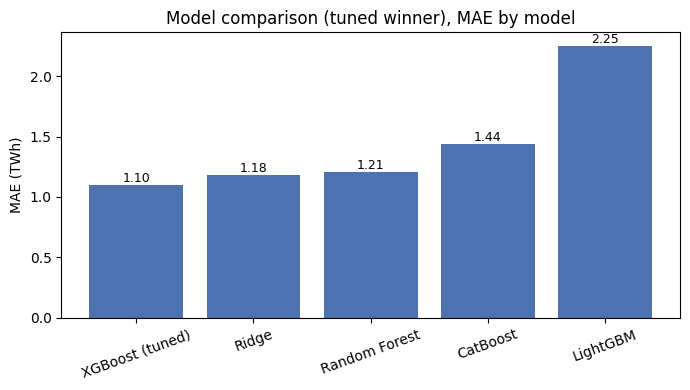

In [8]:
import matplotlib.pyplot as plt
from src.plots import plot_model_comparison_static, plot_actual_vs_predicted

DISPLAY_NAMES = {
    "xgboost": "XGBoost (tuned)", "ridge": "Ridge", "random_forest": "Random Forest",
    "catboost": "CatBoost", "lightgbm": "LightGBM", "dummy": "DummyRegressor (baseline)",
}

comparison_final = comparison[comparison["model"] != winner_name].copy()
comparison_final = pd.concat([comparison_final, pd.DataFrame([{
    "model": winner_name, "MAE": round(final_metrics["MAE"], 2),
    "MAE_CI95": f"[{final_metrics['MAE_ci_low']:.2f}, {final_metrics['MAE_ci_high']:.2f}]",
    "RMSE": round(final_metrics["RMSE"], 2), "R2": round(final_metrics["R2"], 3),
    "R2_CI95": f"[{final_metrics['R2_ci_low']:.3f}, {final_metrics['R2_ci_high']:.3f}]",
    "WMAE": round(final_metrics["WMAE"], 2),
}])], ignore_index=True)
comparison_final["model"] = comparison_final["model"].map(DISPLAY_NAMES)
comparison_final.to_csv("../data/processed/model_comparison_final.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
plot_model_comparison_static(
    comparison_final[comparison_final["model"] != "DummyRegressor (baseline)"],
    metric="MAE", ax=ax, title="Model comparison (tuned winner), MAE by model",
)
plt.tight_layout()
plt.savefig("../reports/figures/model_comparison.png", dpi=110)
plt.show()

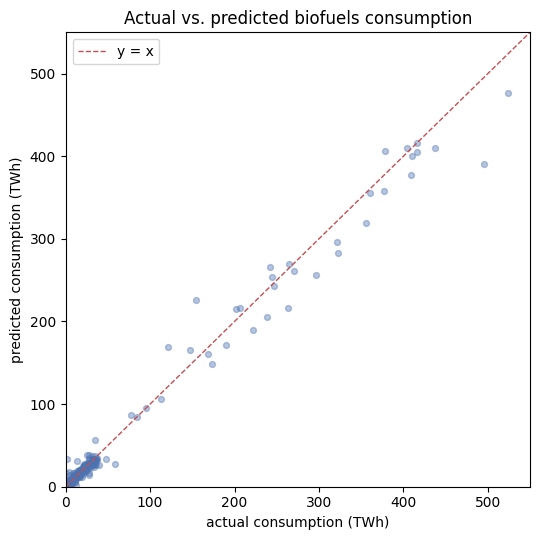

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
plot_actual_vs_predicted(y_true_final, y_pred_final, ax=ax)
plt.tight_layout()
plt.savefig("../reports/figures/actual_vs_predicted.png", dpi=110)
plt.show()

## Interpretability (SHAP)

In [10]:
final_pipe = make_pipeline(winner_name, model=_build_model(winner_name, final_params))
X_all = df[NUM_FEATURES + CAT_FEATURES_CATBOOST]
y_all = df[TARGET]
final_pipe.fit(X_all, y_all)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

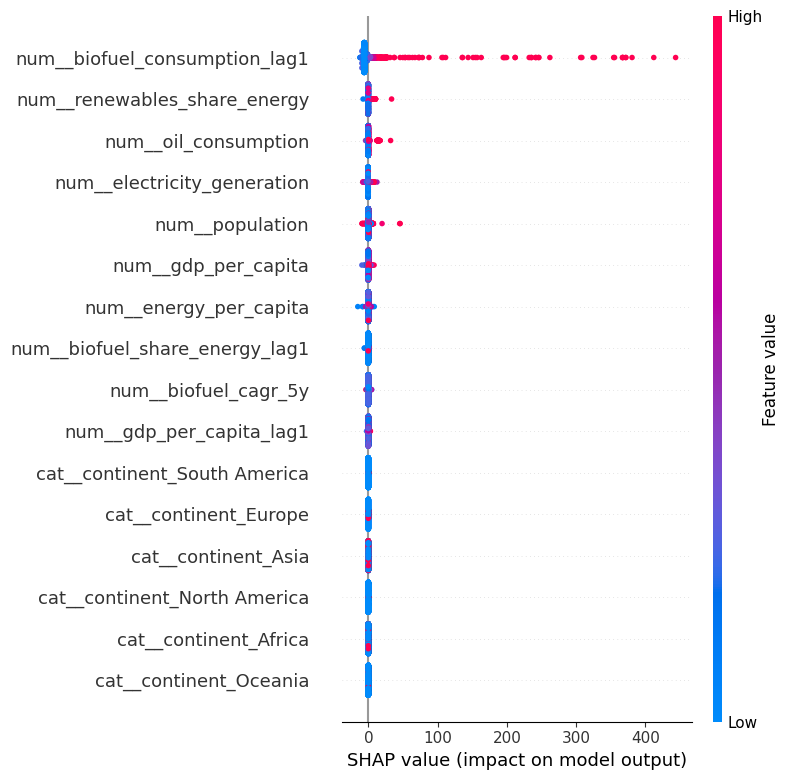

In [11]:
import shap

if winner_name == "catboost":
    Xt = final_pipe.preprocessor.transform(X_all)
    feature_names = final_pipe.get_feature_names()
    explainer = shap.TreeExplainer(final_pipe.model)
    shap_values = explainer.shap_values(Xt)
    shap.summary_plot(shap_values, Xt, feature_names=feature_names, show=False)
elif winner_name in ("xgboost", "lightgbm", "random_forest"):
    Xt = final_pipe.named_steps["preprocessor"].transform(X_all)
    feature_names = list(final_pipe.named_steps["preprocessor"].get_feature_names_out())
    explainer = shap.TreeExplainer(final_pipe.named_steps["model"])
    shap_values = explainer.shap_values(Xt)
    shap.summary_plot(shap_values, Xt, feature_names=feature_names, show=False)
else:
    print(f"SHAP TreeExplainer doesn't apply directly to {winner_name} (a linear model); "
          f"coefficients are reported instead.")

import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary.png", dpi=110, bbox_inches="tight")
plt.show()

## Save the final model and tables for the rest of the repo

In [12]:
import joblib

joblib.dump(final_pipe, "../models/final_model.pkl")
comparison.to_csv("../data/processed/model_comparison.csv", index=False)
df.to_csv("../data/processed/panel_features.csv", index=False)

years_final = np.concatenate([np.full(len(f["y_true"]), f["year"]) for f in final_folds])
predictions_out = pd.DataFrame({
    "country": countries_final,
    "year": years_final,
    "biofuel_consumption_actual": y_true_final,
    "biofuel_consumption_predicted": y_pred_final,
    "top80_consumer": np.isin(countries_final, list(top80_countries)).astype(int),
})
predictions_out.to_csv("../data/processed/predictions_cv.csv", index=False)

print("Final model saved to models/final_model.pkl")
print(f"Winning model: {winner_name}, final params: {final_params}")
predictions_out.head()

Final model saved to models/final_model.pkl
Winning model: xgboost, final params: {'n_estimators': 267, 'max_depth': 8, 'learning_rate': 0.10459854480992457}


,country,year,biofuel_consumption_actual,biofuel_consumption_predicted,top80_consumer
0,Algeria,2010,0.000,-0.014684,0
1,Angola,2010,0.000,0.001226,0
2,Argentina,2010,5.923,0.002352,0
3,Australia,2010,2.577,2.578341,0
4,Austria,2010,5.188,8.642879,0
